# DTS 204 – Statistical Computing, Inference and Modelling
## Lab Assessment: Palmer Penguins Dataset Analysis

**Dataset:** `penguins` (Palmer Penguins), loaded from `DTS_204_Dataset.xlsx`.

**Requirements:** `pandas`, `numpy`, `scipy`, `matplotlib`, `seaborn`
```
pip install pandas numpy scipy matplotlib seaborn openpyxl
```

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)

## Task 1: Data Exploration and Preprocessing

### 1. Load the dataset

In [2]:
df = pd.read_excel("DTS_204_Dataset.xlsx")   # penguins dataset
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### 2. Display the first six rows

In [3]:
df.head(6)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


### 3. Check for missing values

**Handling strategy:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` and `body_mass_g` each have 2 missing values (the same 2 rows), and `sex` has 11 missing values. Since missingness is a very small fraction (<4%) of the 344 rows, we use listwise deletion (`dropna`) for any analysis that needs complete cases (t-test, proportion test, correlation, regression). For summary statistics we simply ignore missing values (`na.rm` equivalent).

In [4]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

### 4. Summary statistics for numerical variables

In [5]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
summary = df[num_cols].agg(["mean", "median", "std", "min", "max"]).T
summary["range"] = summary["max"] - summary["min"]
summary

,mean,median,std,min,max,range
bill_length_mm,43.921930,44.45,5.459584,32.1,59.6,27.5
bill_depth_mm,17.151170,17.30,1.974793,13.1,21.5,8.4
flipper_length_mm,200.915205,197.00,14.061714,172.0,231.0,59.0
body_mass_g,4201.754386,4050.00,801.954536,2700.0,6300.0,3600.0


## Task 2: Hypothesis Testing

### i. Two-sample t-test: `body_mass_g`, Adelie vs Gentoo

- **H0:** There is no significant difference in mean body mass between Adelie and Gentoo penguins.
- **H1:** There is a significant difference.

Decision rule: reject H0 if p-value < 0.05.

In [6]:
adelie = df.loc[df.species == "Adelie", "body_mass_g"].dropna()
gentoo = df.loc[df.species == "Gentoo", "body_mass_g"].dropna()

t_stat, p_val_t = stats.ttest_ind(adelie, gentoo, equal_var=False)  # Welch's t-test

print(f"Adelie:  n={len(adelie)}, mean={adelie.mean():.2f}, sd={adelie.std():.2f}")
print(f"Gentoo:  n={len(gentoo)}, mean={gentoo.mean():.2f}, sd={gentoo.std():.2f}")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val_t:.3e}")

Adelie:  n=151, mean=3700.66, sd=458.57
Gentoo:  n=123, mean=5076.02, sd=504.12
t-statistic = -23.3860, p-value = 7.710e-65


**Conclusion:** p < 0.05, so we reject H0. There is very strong evidence that Adelie and Gentoo penguins differ in mean body mass — Gentoo penguins are on average about 1,375 g heavier than Adelie penguins.

### ii. One-sample proportion test: proportion of males vs 50%

- **H0:** Proportion of males = 50%
- **H1:** Proportion of males ≠ 50%

In [7]:
sex_data = df.dropna(subset=["sex"])
n_total = len(sex_data)
n_male = (sex_data["sex"] == "male").sum()

prop_result = stats.binomtest(n_male, n_total, p=0.5, alternative="two-sided")

print(f"n_male={n_male}, n_total={n_total}, observed proportion={n_male/n_total:.4f}")
print(f"p-value = {prop_result.pvalue:.4f}")

n_male=168, n_total=333, observed proportion=0.5045
p-value = 0.9127


**Conclusion:** p > 0.05, so we fail to reject H0. There is no statistically significant evidence that the proportion of male penguins differs from 50%.

## Task 3: Correlation Analysis

In [8]:
corr_data = df[num_cols].dropna()
corr_matrix = corr_data.corr(method="pearson")
corr_matrix.round(3)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


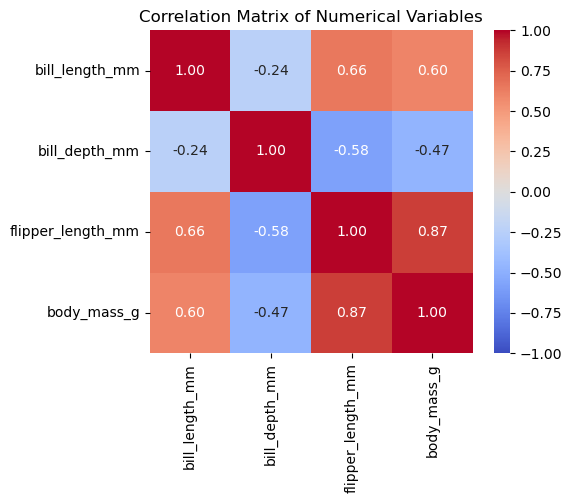

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            fmt=".2f", square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=150)
plt.show()

**Discussion:**
- Flipper length and body mass are strongly positively correlated (r = 0.871).
- Bill depth is negatively correlated with flipper length (r = -0.584) and body mass (r = -0.472), largely reflecting species differences.
- Bill length and body mass show a moderate positive correlation (r = 0.595).
- Bill length and bill depth are weakly negatively correlated (r = -0.235), the weakest relationship in the matrix.

## Task 4: Regression Modeling

### i. Simple linear regression: `body_mass_g ~ flipper_length_mm`

In [10]:
reg_data = df.dropna(subset=["flipper_length_mm", "bill_length_mm",
                              "bill_depth_mm", "body_mass_g"]).copy()

x = reg_data["flipper_length_mm"].values
y = reg_data["body_mass_g"].values
slope, intercept, r_value, p_value_simple, std_err = stats.linregress(x, y)

print(f"body_mass_g = {intercept:.2f} + {slope:.3f} * flipper_length_mm")
print(f"R-squared = {r_value**2:.4f}, p-value (slope) = {p_value_simple:.3e}, "
      f"SE(slope) = {std_err:.3f}")

body_mass_g = -5780.83 + 49.686 * flipper_length_mm
R-squared = 0.7590, p-value (slope) = 4.371e-107, SE(slope) = 1.518


**Interpretation:** Each additional millimetre of flipper length is associated with an average increase of about 49.7 g in body mass. The model explains roughly 76% of the variation in body mass (R² = 0.759).

### ii. Multiple linear regression

In [11]:
def ols_with_stats(X_df, y, feature_names):
    """Manual OLS via normal equations, returning coefficients, SEs, t, p, R2."""
    X = np.column_stack([np.ones(len(X_df))] + [X_df[c].values for c in feature_names])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat
    n, k = X.shape[0], X.shape[1] - 1
    sse = np.sum(resid ** 2)
    sst = np.sum((y - y.mean()) ** 2)
    r2 = 1 - sse / sst
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    sigma2 = sse / (n - k - 1)
    xtx_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(sigma2 * xtx_inv))
    t_vals = beta / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_vals), df=n - k - 1))
    mse = sigma2
    msr = (sst - sse) / k
    f_stat = msr / mse
    f_p = 1 - stats.f.cdf(f_stat, k, n - k - 1)
    return {
        "names": ["Intercept"] + feature_names,
        "coef": beta, "se": se, "t": t_vals, "p": p_vals,
        "r2": r2, "adj_r2": adj_r2, "f_stat": f_stat, "f_p": f_p, "n": n,
    }

features = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
mlr = ols_with_stats(reg_data, y, features)

for name, b, se, t, p in zip(mlr["names"], mlr["coef"], mlr["se"], mlr["t"], mlr["p"]):
    print(f"{name:>20s}: coef={b:10.4f}  SE={se:8.4f}  t={t:8.4f}  p={p:.4g}")
print(f"R-squared = {mlr['r2']:.4f}, Adjusted R-squared = {mlr['adj_r2']:.4f}")
print(f"F-statistic = {mlr['f_stat']:.2f}, p-value = {mlr['f_p']:.3e}")

           Intercept: coef=-6424.7647  SE=561.4693  t=-11.4428  p=0
   flipper_length_mm: coef=   50.2692  SE=  2.4771  t= 20.2932  p=0
      bill_length_mm: coef=    4.1618  SE=  5.3291  t=  0.7810  p=0.4354
       bill_depth_mm: coef=   20.0495  SE= 13.6939  t=  1.4641  p=0.1441
R-squared = 0.7615, Adjusted R-squared = 0.7594
F-statistic = 359.67, p-value = 1.110e-16


**Interpretation:** The multiple regression R² (0.761) is only marginally higher than the simple model's (0.759) — flipper length alone already captures almost all the explainable variation. Only `flipper_length_mm` is statistically significant (p < 0.001); neither `bill_length_mm` (p = 0.435) nor `bill_depth_mm` (p = 0.144) is significant once flipper length is included, likely due to multicollinearity among the bill/flipper measurements. Given the negligible gain in fit, the simpler single-predictor model is preferable on grounds of parsimony.

## Task 5: Visualization

### 1. Scatter plot with regression line

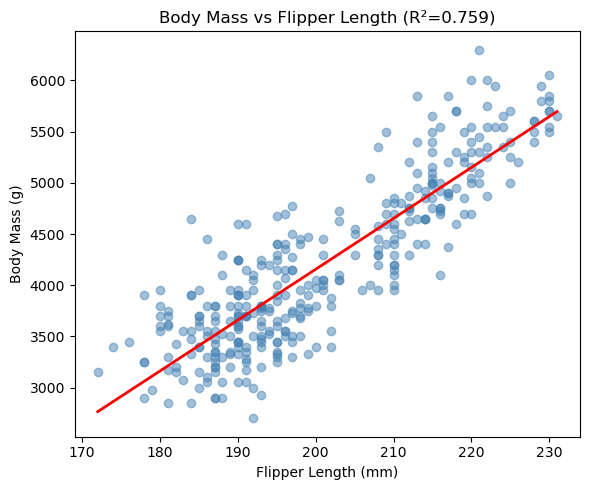

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.5, color="steelblue")
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, intercept + slope * xs, color="red", linewidth=2)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title(f"Body Mass vs Flipper Length (R\u00b2={r_value**2:.3f})")
plt.tight_layout()
plt.savefig("scatter_regression.png", dpi=150)
plt.show()

### 2. Boxplot: body mass by species

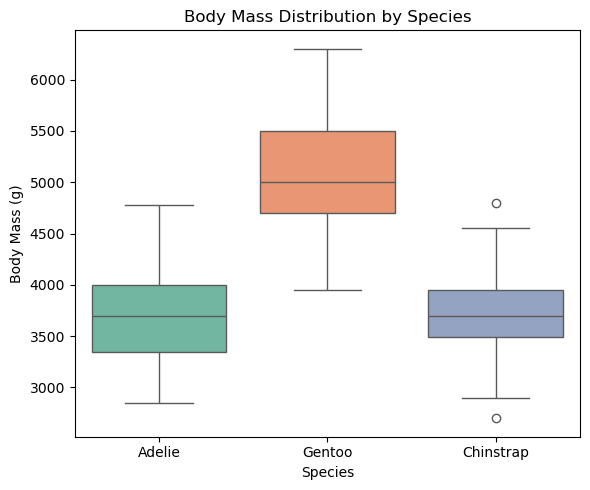

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="species", y="body_mass_g", hue="species",
            palette="Set2", legend=False)
plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.savefig("boxplot_species.png", dpi=150)
plt.show()

### 3. Histogram of body mass with normal curve overlay

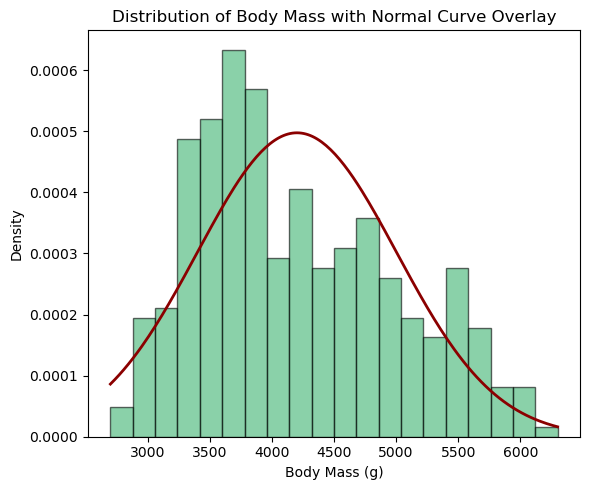

In [14]:
mass = df["body_mass_g"].dropna()
plt.figure(figsize=(6, 5))
plt.hist(mass, bins=20, density=True, alpha=0.6, color="mediumseagreen",
         edgecolor="black")
mu, sigma = mass.mean(), mass.std()
xs = np.linspace(mass.min(), mass.max(), 200)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), color="darkred", linewidth=2)
plt.xlabel("Body Mass (g)")
plt.ylabel("Density")
plt.title("Distribution of Body Mass with Normal Curve Overlay")
plt.tight_layout()
plt.savefig("histogram_normal.png", dpi=150)
plt.show()

## Summary

- **t-test:** Adelie vs. Gentoo body mass differs significantly (t = -23.39, p ≈ 0).
- **Proportion test:** Sex ratio is consistent with 50/50 (p = 0.913).
- **Correlation:** Flipper length and body mass are the most strongly related pair (r = 0.871).
- **Regression:** Flipper length alone predicts body mass almost as well as all three predictors combined (R² = 0.759 vs 0.761).